In [1]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [3]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [4]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

In [5]:
uber["hora"] = uber["pickup_datetime"].dt.hour
uber["minuto"] = uber["pickup_datetime"].dt.minute
uber["fecha"] = uber["pickup_datetime"].dt.date

In [20]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [21]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

### Valores nulos

In [6]:
uber.isnull().sum()

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
hora                 0
minuto               0
fecha                0
dtype: int64

In [7]:
uber.dropna(inplace=True)

### Valores atipicos

In [8]:
viajes_sin_moverse = uber[
    (uber["dropoff_latitude"] == uber["pickup_latitude"]) & 
    (uber["dropoff_longitude"] == uber["pickup_longitude"]) & 
    (uber["fare_amount"] == 0)]
print(f"Viajes sin movimiento pero sin costos son: {viajes_sin_moverse["passenger_count"].count()}") # Hay 2 viajes sin moverse
viajes_con_movimiento_sin_costo = uber[
    ((uber["dropoff_latitude"] != uber["pickup_latitude"]) | 
    (uber["dropoff_longitude"] != uber["pickup_longitude"])) & 
    (uber["fare_amount"] == 0)]
print(f"Viajes con movimiento pero sin costos son: {viajes_con_movimiento_sin_costo["passenger_count"].count()}") # Hay 3 viajes con movimiento sin costo

Viajes sin movimiento pero sin costos son: 2
Viajes con movimiento pero sin costos son: 3


In [9]:
precios_negativos = uber[uber["fare_amount"] < 0]
print(f"Viajes con costos negativos: {precios_negativos["passenger_count"].count()}") # hay 17 valores negativos
precios_negativos

Viajes con costos negativos: 17


,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hora,minuto,fecha
63395,30260042,2015-03-03 23:07:41.000000800,-5.00,2015-03-03 23:07:41+00:00,-73.992249,40.748936,-73.988518,40.748180,1,23,7,2015-03-03
71246,51325304,2010-02-11 21:47:10.000000100,-3.30,2010-02-11 21:47:10+00:00,-73.952725,40.768235,-73.949928,40.772208,2,21,47,2010-02-11
79903,50284253,2015-05-01 14:43:02.000000400,-3.50,2015-05-01 14:43:02+00:00,-73.982430,40.775024,-73.981750,40.778439,1,14,43,2015-05-01
89322,26673143,2010-03-09 08:26:10.000000600,-49.57,2010-03-09 08:26:10+00:00,-73.972772,40.785657,-73.972867,40.785500,5,8,26,2010-03-09
92063,10267585,2010-03-12 08:49:10.000000200,-23.70,2010-03-12 08:49:10+00:00,-73.952740,40.768233,-74.007028,40.707338,3,8,49,2010-03-12
98875,51135168,2015-03-20 21:31:14.000000700,-52.00,2015-03-20 21:31:14+00:00,-74.000359,40.728729,-74.005699,40.728680,5,21,31,2015-03-20
104080,21688700,2010-03-09 20:25:10.000000200,-7.30,2010-03-09 20:25:10+00:00,-73.952623,40.766942,-73.953787,40.784882,1,20,25,2010-03-09
111589,13971251,2015-02-23 19:26:44.000000400,-52.00,2015-02-23 19:26:44+00:00,-73.984665,40.759026,0.000000,0.000000,5,19,26,2015-02-23
139272,40714150,2010-02-23 18:52:10.000000300,-6.90,2010-02-23 18:52:10+00:00,-73.988727,40.736445,-73.977622,40.750487,1,18,52,2010-02-23
148803,34933571,2010-02-12 10:50:10.000000500,-5.70,2010-02-12 10:50:10+00:00,-73.977300,40.742783,-73.988837,40.747465,3,10,50,2010-02-12


In [10]:
#eliminamos donde dropoff_latitude y dropoff_longitude sean iguales a 0
uber = uber[(uber["dropoff_latitude"] != 0) & (uber["dropoff_longitude"] != 0)]

#eliminamos con costos iguales a 0
uber = uber[
    (uber["fare_amount"] != 0)
]

In [11]:
#transformamos los valores de la columna fare_amount a positivos

uber["fare_amount"] = abs(uber["fare_amount"])

In [19]:
porcentaje_eliminados = round((200000- len(uber)) / 200000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 1.88% de los datos


In [12]:
uber.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196230 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                196230 non-null  int64              
 1   date               196230 non-null  datetime64[ns]     
 2   fare_amount        196230 non-null  float64            
 3   pickup_datetime    196230 non-null  datetime64[ns, UTC]
 4   pickup_longitude   196230 non-null  float64            
 5   pickup_latitude    196230 non-null  float64            
 6   dropoff_longitude  196230 non-null  float64            
 7   dropoff_latitude   196230 non-null  float64            
 8   passenger_count    196230 non-null  int64              
 9   hora               196230 non-null  int32              
 10  minuto             196230 non-null  int32              
 11  fecha              196230 non-null  object             
dtypes: datetime64[ns, UTC](1), datetime

In [13]:
q1 = uber["fare_amount"].quantile(0.25)
q3 = uber["fare_amount"].quantile(0.75)

iqr = q3 - q1
umbral_inferior = max(q1 - 1.5 * iqr,0)
umbral_superior = q3 + 1.5 * iqr

precios_fuera_de_rango = uber[(uber["fare_amount"] < umbral_inferior) | (uber["fare_amount"] > umbral_superior)]
print(f"Viajes con costos fuera de rango: {precios_fuera_de_rango["passenger_count"].count()}") # hay 17173 valores fuera de rango

Viajes con costos fuera de rango: 16813


0         1.045968
1         1.527076
2         3.129460
3         1.032522
4         2.780916
            ...   
199995    0.069724
199996    1.165102
199997    7.984818
199998    2.199477
199999    3.366455
Name: distancia, Length: 196230, dtype: float64

### Graficos

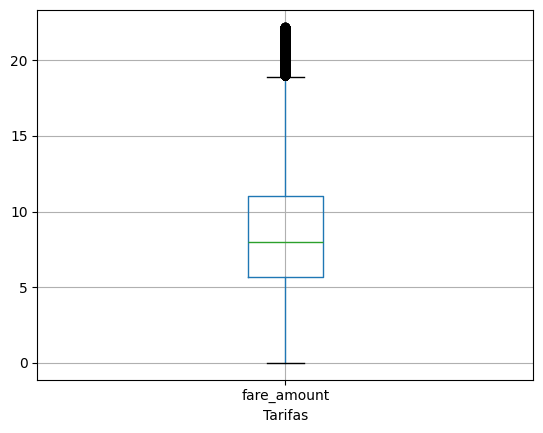

In [16]:
uber[(uber["fare_amount"] > umbral_inferior) & (uber["fare_amount"] < umbral_superior)].boxplot(column='fare_amount')
plt.xlabel("Tarifas")
plt.show()

In [17]:
uber.boxplot(columns = "distancia")
plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'columns'